# MLDoctor - Case1

For a high-end grooming application, the engineering team developed a model to discern clean-shaven faces. During the “Lab Phase,” the model performed exceptionally well, trained and validated on studio-quality images. It achieved a near-perfect accuracy on the Internal test Set. However, once deployed in a mobile application, the model’s accuracy significantly decreased. Users have reported that the model frequently fails. What happened during the transition from the “Studio” to the “Mobile App”? Please elaborate on the identified problem, explain how it was identified, and provide a recommended solution. 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.metrics import ConfusionMatrixDisplay
from utils import audit_utils

In [23]:
device = audit_utils.setup_env()

internal_path = 'Case1Dataset/test_internal'
external_path = 'Case1Dataset/test_external'

test_internal_loader, test_external_loader, test_internal_dataset, test_external_dataset = audit_utils.get_dataloaders(
    internal_path, external_path, batch_size=16, num_workers=0
)

Using device: cuda:0


Class mapping: {'negative': 0, 'positive': 1}


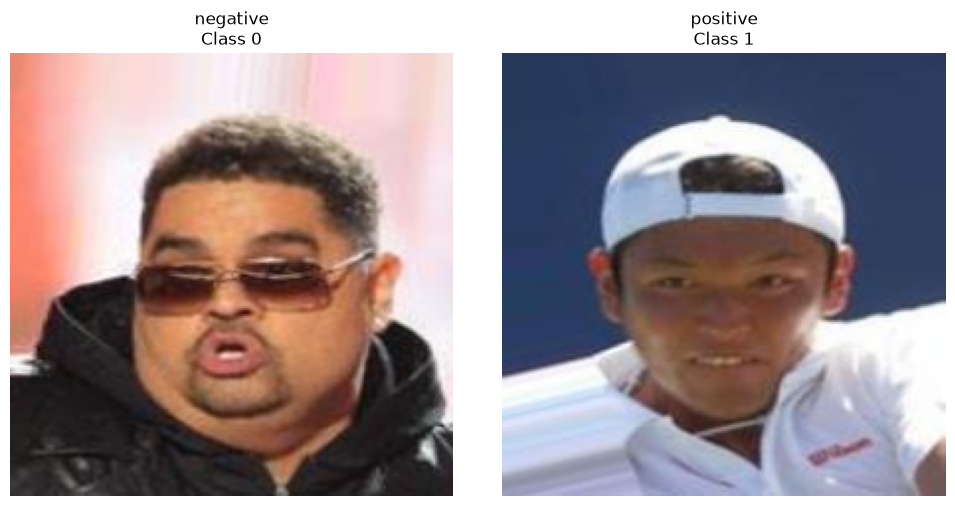

In [ ]:
# Check class names and corresponding indices
print("Class mapping:", test_internal_dataset.class_to_idx)

# Display one sample image from each class
fig, axes = plt.subplots(1, len(test_internal_dataset.classes), figsize=(10, 5))

for class_idx, class_name in enumerate(test_internal_dataset.classes):
    
    # Find the first sample belonging to this class
    sample_idx = test_internal_dataset.targets.index(class_idx)
    image, label = test_internal_dataset[sample_idx]

    # Denormalise for display
    image = image.cpu().numpy().transpose(1, 2, 0)
    image = image * np.array(audit_utils.imagenet_stds) + np.array(audit_utils.imagenet_means)
    image = np.clip(image, 0, 1)

    axes[class_idx].imshow(image)
    axes[class_idx].set_title(f"{class_name}\nClass {class_idx}")
    axes[class_idx].axis("off")

plt.tight_layout()
plt.savefig('plot/case1_samples.png')
plt.show()

In [ ]:
# Load the model
resnet_frozen = audit_utils.setup_model(2, "resnet_frozen_best_case1.pth", device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

In [26]:
all_predictions, all_labels = audit_utils.evaluate_model(resnet_frozen, test_internal_loader, test_external_loader, device)

for split in ['internal', 'external']:
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 47/47 [00:02<00:00, 16.16it/s]

internal set - Accuracy: 0.937
external set - Accuracy: 0.619


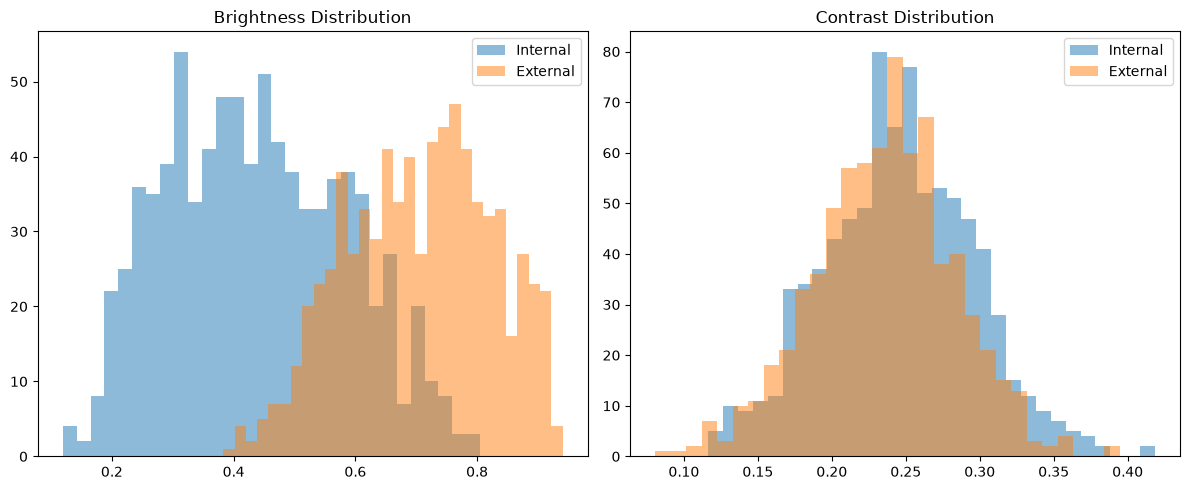

In [27]:
# Quantitative Dataset Comparison
audit_utils.plot_image_stats(test_internal_dataset, test_external_dataset, save_prefix='plot/case1_')


===== INTERNAL SET =====
Accuracy : 0.937
Precision: 0.914
Recall   : 0.964
F1-score : 0.939


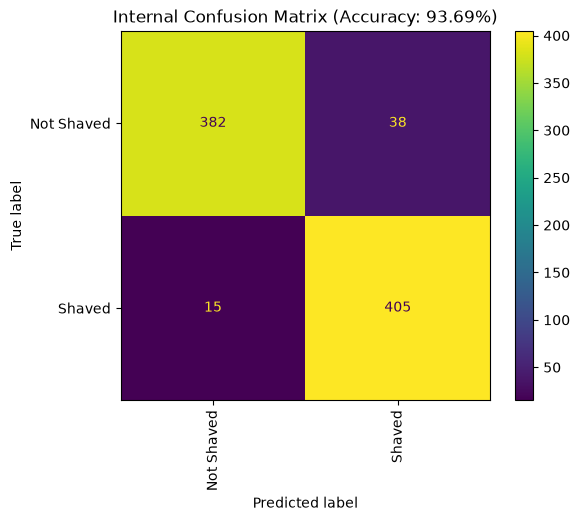

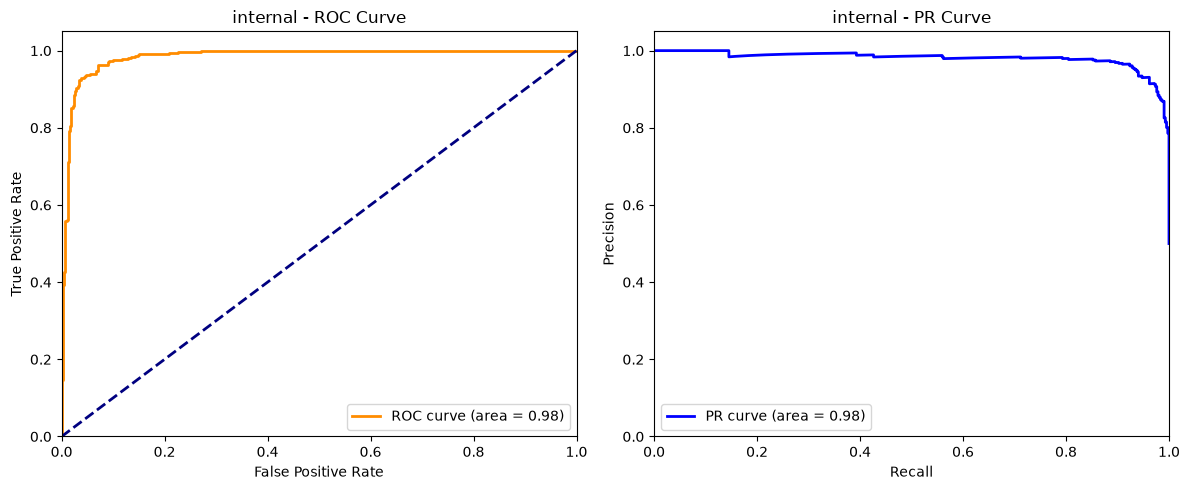


===== EXTERNAL SET =====
Accuracy : 0.619
Precision: 0.568
Recall   : 0.989
F1-score : 0.722


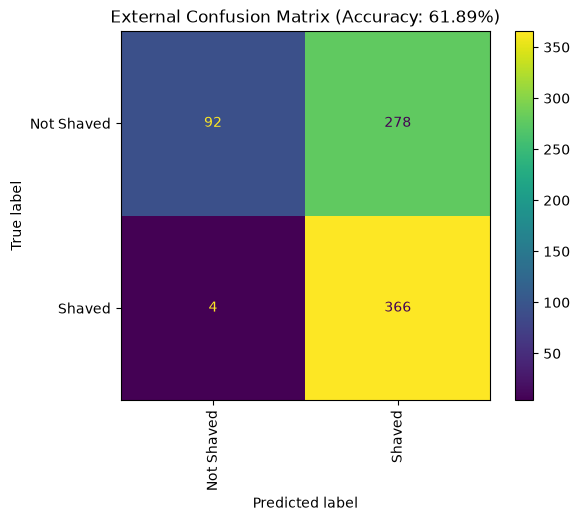

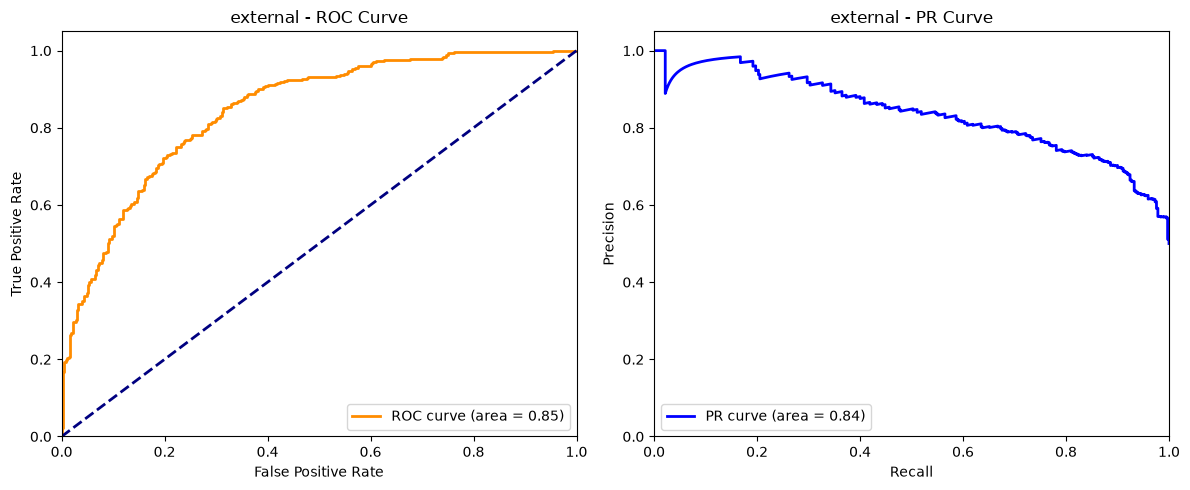

In [28]:
threshold = 0.5
for split in ['internal', 'external']:
    labels = all_labels[split]
    probs_shaved = all_predictions[split][:, 1]
    preds = probs_shaved >= threshold

    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = audit_utils.compute_metrics(labels, probs_shaved, threshold=threshold)

    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels, preds, display_labels=['Not Shaved', 'Shaved'], xticks_rotation='vertical'
    )
    plt.title(f'{split.capitalize()} Confusion Matrix (Accuracy: {accuracy * 100:.2f}%)')
    plt.savefig(f'plot/case1_cm_{split}.png')
    plt.show()
    
    # Plot ROC and PR curves
    audit_utils.plot_roc_pr_curves(labels, probs_shaved, split, save_prefix='plot/case1_')

False positives increased substantially from 38 in the internal test set to 278 in the external test set, indicating that many non-shaved faces were incorrectly classified as shaved.
  
Consequently, precision for the shaved class decreased significantly.  

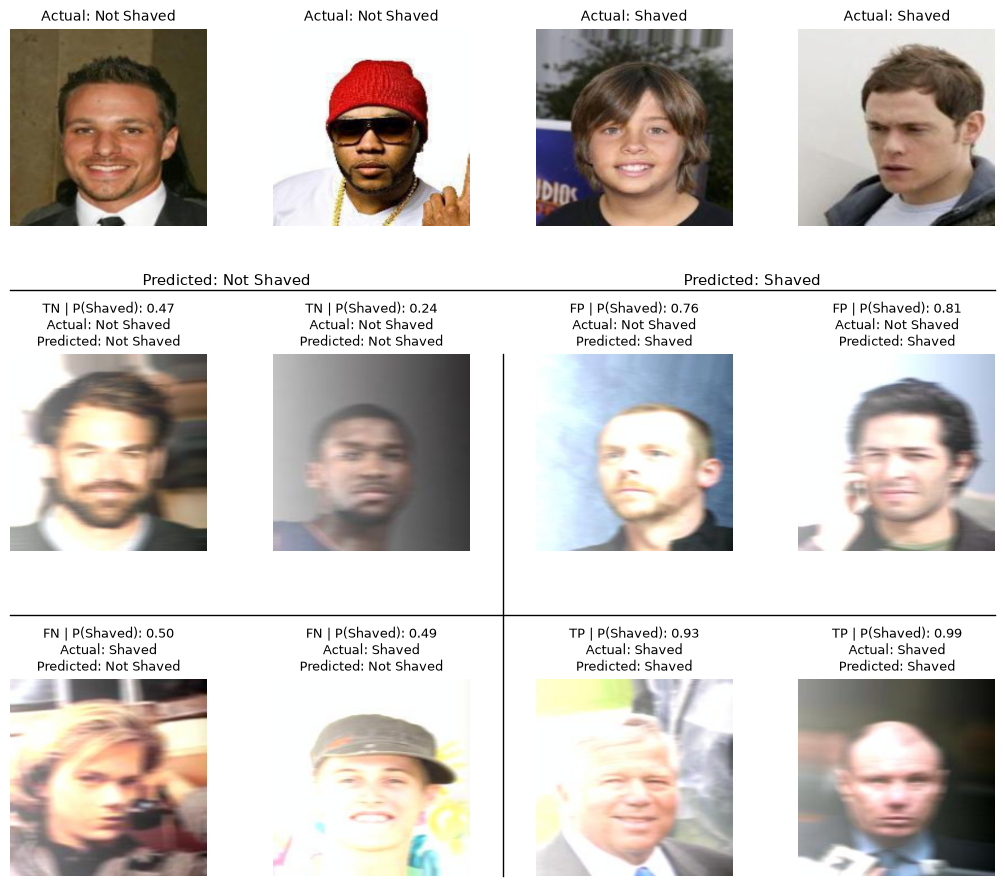

In [ ]:
# Use the external predictions already computed above
labels = all_labels['external']
probs_shaved = all_predictions['external'][:,1]
preds = probs_shaved >= threshold

# Identify external samples by confusion matrix outcome
tn_indices = np.where((labels == 0) & (preds == 0))[0]
fp_indices = np.where((labels == 0) & (preds == 1))[0]
fn_indices = np.where((labels == 1) & (preds == 0))[0]
tp_indices = np.where((labels == 1) & (preds == 1))[0]

# Identify internal samples by actual class
internal_labels = all_labels['internal']
internal_not_shaved = np.where(internal_labels == 0)[0]
internal_shaved = np.where(internal_labels == 1)[0]

# Select two samples from each group
np.random.seed(0)
internal_indices = np.concatenate([
    np.random.choice(internal_not_shaved,2,replace=False),
    np.random.choice(internal_shaved,2,replace=False)
])
external_indices = [
    np.random.choice(tn_indices,2,replace=False),
    np.random.choice(fp_indices,2,replace=False),
    np.random.choice(fn_indices,2,replace=False),
    np.random.choice(tp_indices,2,replace=False)
]

# Denormalize images for visualization
def denormalize_image(image):
    image = image.numpy().transpose(1,2,0)
    image = image*np.array(audit_utils.imagenet_stds)+np.array(audit_utils.imagenet_means)
    return np.clip(image,0,1)

# Create the figure
fig,axes = plt.subplots(3,4,figsize=(13,11))

# Plot internal samples: Not Shaved | Shaved
for col,idx in enumerate(internal_indices):
    image,label = test_internal_dataset[idx]
    actual = 'Shaved' if label == 1 else 'Not Shaved'
    axes[0,col].imshow(denormalize_image(image))
    axes[0,col].set_title(f'Actual: {actual}',fontsize=10)
    axes[0,col].axis('off')

# Arrange external samples as TN | FP / FN | TP
groups = [
    (0,0,external_indices[0],'TN'),
    (0,2,external_indices[1],'FP'),
    (1,0,external_indices[2],'FN'),
    (1,2,external_indices[3],'TP')
]

for row,start_col,indices,result in groups:
    for offset,idx in enumerate(indices):
        image,label = test_external_dataset[idx]
        pred = int(preds[idx])
        actual = 'Shaved' if label == 1 else 'Not Shaved'
        predicted = 'Shaved' if pred == 1 else 'Not Shaved'
        ax = axes[row+1,start_col+offset]
        ax.imshow(denormalize_image(image))
        ax.set_title(
            f'{result} | P(Shaved): {probs_shaved[idx]:.2f}\n'
            f'Actual: {actual}\n'
            f'Predicted: {predicted}',
            fontsize=9
        )
        ax.axis('off')

# Label internal and external sections
axes[0,0].set_ylabel('Internal',fontsize=12,labelpad=10)
axes[1,0].set_ylabel('Actual:\nNot Shaved',fontsize=11,labelpad=10)
axes[2,0].set_ylabel('Actual:\nShaved',fontsize=11,labelpad=10)

# Add predicted-class headings for the external confusion matrix
axes[1,0].text(
    1.1,1.35,'Predicted: Not Shaved',
    transform=axes[1,0].transAxes,
    ha='center',fontsize=11
)
axes[1,2].text(
    1.1,1.35,'Predicted: Shaved',
    transform=axes[1,2].transAxes,
    ha='center',fontsize=11
)

# Adjust spacing
plt.subplots_adjust(hspace=0.65,wspace=0.2)
fig.canvas.draw()

# Separate internal and external samples
y_internal = (axes[0,0].get_position().y0+axes[1,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [axes[0,0].get_position().x0,axes[0,3].get_position().x1],
    [y_internal,y_internal],
    transform=fig.transFigure,color='black',linewidth=1
))

# Separate predicted Not Shaved and Shaved
x_mid = (axes[1,1].get_position().x1+axes[1,2].get_position().x0)/2
fig.add_artist(plt.Line2D(
    [x_mid,x_mid],
    [axes[2,0].get_position().y0,axes[1,0].get_position().y1],
    transform=fig.transFigure,color='black',linewidth=1
))

# Separate actual Not Shaved and Shaved
y_mid = (axes[1,0].get_position().y0+axes[2,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [axes[1,0].get_position().x0,axes[1,3].get_position().x1],
    [y_mid,y_mid],
    transform=fig.transFigure,color='black',linewidth=1
))

plt.savefig('plot/case1_predictions.png')
plt.show()

The internal test images were generally clear and well-defined, whereas the external images seemed to be noticeably brighter and more overexposed, with some images also appearing blurrier.

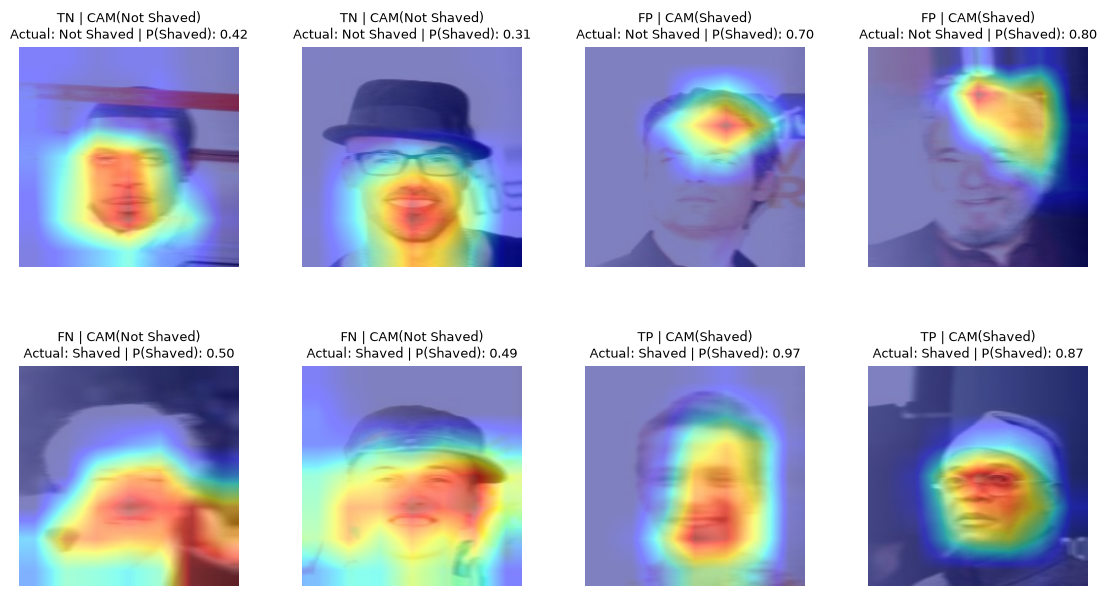

In [30]:
# Use the external predictions already computed above
labels = all_labels['external']
probs_shaved = all_predictions['external'][:,1]
preds = probs_shaved >= threshold

# Identify external samples by confusion matrix outcome
tn_indices = np.where((labels == 0) & (preds == 0))[0]
fp_indices = np.where((labels == 0) & (preds == 1))[0]
fn_indices = np.where((labels == 1) & (preds == 0))[0]
tp_indices = np.where((labels == 1) & (preds == 1))[0]

# Select samples from each group
np.random.seed(10)
selected_tn = np.random.choice(tn_indices, 2, replace=False)
selected_fp = np.random.choice(fp_indices, 2, replace=False)
selected_fn = np.random.choice(fn_indices, 2, replace=False)
selected_tp = np.random.choice(tp_indices, 2, replace=False)

# CAM Implementation
activation = {}

def get_activation(name):
    def hook(model, input, output):
        activation[name] = output.detach()
    return hook

target_layer = resnet_frozen.layer4[1].conv2
hook_handle = target_layer.register_forward_hook(get_activation('layer4_conv2'))

cam_groups = [
    ('TN', selected_tn),
    ('FP', selected_fp),
    ('FN', selected_fn),
    ('TP', selected_tp)
]

resnet_frozen.eval()
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

with torch.no_grad():
    for result, indices in cam_groups:
        row = 0 if result in ['TN', 'FP'] else 1
        start_col = 0 if result in ['TN', 'FN'] else 2

        for offset, idx in enumerate(indices):
            x, y = test_external_dataset[idx]
            x = x.to(device).unsqueeze(0)

            # Run inference
            output = resnet_frozen(x)
            pred = torch.argmax(output, dim=1).item()
            prob_shaved = torch.softmax(output, dim=1)[0, 1].item()

            # CAM computation using audit_utils
            conv_feature_map = activation['layer4_conv2'][0]
            fc_weights = resnet_frozen.fc.weight[pred].detach()
            cam = audit_utils.compute_cam(conv_feature_map, fc_weights, image_size=(x.shape[2], x.shape[3]))

            x_display = audit_utils.denormalize_image(x.squeeze(0).cpu())
            actual = 'Shaved' if y == 1 else 'Not Shaved'
            predicted = 'Shaved' if pred == 1 else 'Not Shaved'

            ax = axes[row, start_col + offset]
            ax.imshow(x_display)
            ax.imshow(cam, alpha=0.5, cmap='jet')
            ax.set_title(
                f'{result} | CAM({predicted})\n'
                f'Actual: {actual} | P(Shaved): {prob_shaved:.2f}',
                fontsize=9
            )
            ax.axis('off')

plt.subplots_adjust(hspace=0.45, wspace=0.20)
plt.savefig('plot/case1_cam.png')
plt.show()

hook_handle.remove()

## Evaluation Processing Reasoning

We evaluate the model on both the internal (studio) and external (mobile app) datasets to quantify the performance degradation. We use ROC and Precision-Recall curves to assess the model's discriminative ability independent of the decision threshold, ensuring the failure isn't just a thresholding issue. We calculate brightness/contrast distributions to formally test for covariate shift (domain shift). Finally, we use CAM to visually inspect the spatial regions the model relies on for its decisions, which is crucial for identifying spurious correlations.

## Diagnosis

The root cause of the failure is a **spurious correlation** caused by **covariate shift**. The model failed to learn the actual semantic features of a 'clean-shaven' face (e.g., the chin and jawline). Instead, it learned to rely on confounding environmental features present in the 'Studio' training data (such as studio lighting, specific backgrounds, or high-contrast image artifacts) which are absent in the 'Mobile App' data.

## Evidence

1. **Performance Metrics**: ccuracy dropped from 93.7% to 62.3%, with false positives increasing from 38 to 278 and shaved-class precision decreasing from 0.915 to 0.574 in the confusion matrix.

2. **Distribution Shift**: The brightness and contrast histograms demonstrate a quantitative shift in the image statistics between the internal and external datasets.

3. **CAM Saliency Maps**: For False Positives and False Negatives in the external set, the CAM heatmaps reveal that the model's highest activations are focused on the background, the subject's clothing/collar, or lighting artifacts, rather than the lower half of the face.

## Recommendations

1. **Data Augmentation**: Retrain the model applying aggressive data augmentation (e.g., color jitter, random lighting, background blurring, and random cropping) to force the model to become invariant to lighting and background changes.

2. **Domain Randomization / Diverse Data**: Collect a more representative training dataset that includes mobile-phone quality images with diverse lighting and backgrounds, rather than relying solely on studio-quality images.

3. **Attention/Crop Enforcing**: Consider using a face-detection bounding box to crop the images to just the facial region before passing them to the classifier, removing environmental spurious cues entirely.